In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import random
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel, BertForSequenceClassification
#from transformers import AdamW, 
from transformers import AutoTokenizer
from transformers import AutoModel
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, precision_recall_fscore_support,f1_score
from collections import Counter

from datasets import load_dataset

from ml_moo.scalarization.two_objs_hate_speech import HateSpeechScalarization
from ml_moo import moo
from ml_moo.analysis.pareto_frontier import ParetoFrontier

/home/lineccsa/mestrado/moo_research/moo_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Definir seed para reprodutibilidade
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

In [4]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)


In [5]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 15383
    })
    validation: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 1922
    })
    test: Dataset({
        features: ['id', 'annotators', 'rationales', 'post_tokens'],
        num_rows: 1924
    })
})


In [6]:
# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [7]:
print("GPU disponível:", torch.cuda.is_available())

GPU disponível: True


In [8]:
print("Número de GPUs:", torch.cuda.device_count())

Número de GPUs: 1


In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device

device(type='cuda', index=0)

## Multi task model

In [ ]:
class MultiTaskHateSpeechDataset(Dataset):
    def __init__(self, dataset, tokenizer_name="bert-base-uncased", max_length=128):
        self.dataset = dataset
        self.tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)
        self.max_length = max_length
        self.bert_model = AutoModel.from_pretrained(tokenizer_name)
        self.bert_model.eval()

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        data = self.dataset[idx]

        # Converter lista de tokens em texto
        text = " ".join(data["post_tokens"])

        # Encontrar a moda dos rótulos (classificação de discurso de ódio)
        labels = data["annotators"]["label"]
        label_counts = Counter(labels)
        majority_label = label_counts.most_common(1)[0][0]  # Pega a moda
      
        label_hate = 0 if majority_label == 1 else 1

        # Criar rótulo para discurso de ódio contra gênero (exemplo: "women")
        target_groups = data["annotators"]["target"]
        #label_target = 1 if len(target_groups) > 0 else 0
        count_gender = 0
        count_race = 0

        for i in range(len(target_groups)):
            #print(target_groups[i])
            if ('Women' in target_groups[i] or 'Homosexual' in target_groups[i]):
                count_gender += 1
            # etnias
            if ('Indigenous' in target_groups[i] or 'African' in target_groups[i] or 'Asian' in target_groups[i] or 'Jewish' in target_groups):
                count_race += 1

        gender_hate = 1 if ((count_gender > 0) and (label_hate == 1)) else 0  # 1 se houver ataque a mulheres, 0 caso contrário
        race_hate = 1 if ((count_race > 0) and (label_hate == 1)) else 0

        # Tokenizar texto
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label": torch.tensor(label_hate, dtype=torch.long),
            "gender_hate": torch.tensor(gender_hate, dtype=torch.long),
            "race_hate": torch.tensor(race_hate, dtype=torch.long)
            #"label_target": label_target
            #"embedding": embedding.squeeze(0)
        }

In [11]:
# Criar os datasets para treino, validação e teste
train_dataset = MultiTaskHateSpeechDataset(dataset["train"])
val_dataset = MultiTaskHateSpeechDataset(dataset["train"])
test_dataset = MultiTaskHateSpeechDataset(dataset["train"])

# DataLoaders
batch_size = 8
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_dataloader = DataLoader(val_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

In [ ]:
class MultiTaskModel(nn.Module):
    def __init__(self, model_name="tum-nlp/bert-hateXplain", num_labels=2, dropout_rate=0.3):
        super(MultiTaskModel, self).__init__()
        
        # Camada compartilhada: BERT
        self.shared_bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.shared_bert.config.hidden_size
        # print("hidden size", hidden_size)
        
        # Camadas adicionais compartilhadas
        self.dropout = nn.Dropout(dropout_rate)
        self.shared_fc = nn.Linear(hidden_size, 128)

        self.classifier_hate = nn.Linear(128, num_labels)
        
        self.classifier_target = nn.Linear(128, num_labels)

    def forward(self, input_ids, attention_mask):
        # Passagem pela parte compartilhada
        outputs = self.shared_bert(input_ids=input_ids, attention_mask=attention_mask)

        pooled_output = outputs.last_hidden_state[:, 0, :]  # Token [CLS]
        pooled_output = self.dropout(pooled_output)
        
        # Tarefa 1: Classificação de discurso de ódio
        hate_features = self.shared_fc(pooled_output)
        target_features = self.shared_fc(pooled_output)
        
        # Classificação final
        logits_hate = self.classifier_hate(hate_features)
        logits_target = self.classifier_target(target_features)
        
        return logits_hate, logits_target

In [ ]:
def train_model(model, train_loader, val_loader, epochs=3):
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    # model = MultiTaskHateSpeechModel().to(device)
    model = MultiTaskModel().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
    criterion = nn.CrossEntropyLoss()

    best_val_f1 = 0

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_hate = batch["label"].to(device)
            labels_race = batch["race_hate"].to(device)
            
            optimizer.zero_grad()
                
            logits_hate, logits_target = model(input_ids, attention_mask)

            # Calcular perdas
            loss_hate = criterion(logits_hate, labels_hate)
            loss_target = criterion(logits_target, labels_race)
            
            # Balancear as perdas
            loss = 0.5 * loss_hate + 0.5 * loss_target
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
        avg_train_loss = train_loss / len(train_loader)
        print(f"Epoch {epoch+1} - Average training loss: {avg_train_loss:.4f}")

        # Validação
        val_metrics = evaluate_model(model, val_loader, device)
        print(f"Validation metrics - Hate F1: {val_metrics['hate_f1']:.4f}, Target F1: {val_metrics['target_f1']:.4f}")
        print(f"Validation metrics - Hate ACC: {val_metrics['hate_acc']:.4f}, Target ACC: {val_metrics['target_acc']:.4f}")
        
        # Salvar o melhor modelo
        avg_val_f1 = (val_metrics['hate_f1'] + val_metrics['target_f1']) / 2
        if avg_val_f1 > best_val_f1:
            best_val_f1 = avg_val_f1
            torch.save(model.state_dict(), "best_multitask_hate_model.pt")
            print("Saved best model checkpoint.")
    return model

In [14]:
# Função de avaliação
def evaluate_model(model, dataloader, device):
    model.eval()
    
    all_preds_hate = []
    all_true_hate = []
    all_preds_target = []
    all_true_target = []
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_hate = batch["label"]
            labels_target = batch["race_hate"]
            
            logits_hate, logits_target = model(input_ids, attention_mask)
            
            preds_hate = torch.argmax(logits_hate, dim=1).cpu().numpy()
            preds_target = torch.argmax(logits_target, dim=1).cpu().numpy()
            
            all_preds_hate.extend(preds_hate)
            all_true_hate.extend(labels_hate.numpy())
            all_preds_target.extend(preds_target)
            all_true_target.extend(labels_target.numpy())
    
    # Calcular métricas
    hate_acc = accuracy_score(all_true_hate, all_preds_hate)
    hate_f1 = f1_score(all_true_hate, all_preds_hate)
    target_acc = accuracy_score(all_true_target, all_preds_target)
    target_f1 = f1_score(all_true_target, all_preds_target)
    
    return {
        "hate_acc": hate_acc,
        "hate_f1": hate_f1,
        "target_acc": target_acc,
        "target_f1": target_f1
    }

In [15]:
# Instanciar e treinar o modelo
model = MultiTaskModel(model_name)
model = train_model(model, train_dataloader, valid_dataloader, epochs=3)

# Avaliar no conjunto de teste
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_metrics = evaluate_model(model, test_dataloader, device)

print("\nTest Results:")
print(f"Hate Speech Detection - Accuracy: {test_metrics['hate_acc']:.4f}, F1: {test_metrics['hate_f1']:.4f}")
print(f"Target Classification - Accuracy: {test_metrics['target_acc']:.4f}, F1: {test_metrics['target_f1']:.4f}")


Epoch 1/3 - Training: 100%|██████████| 1923/1923 [00:29<00:00, 65.61it/s]


Epoch 1 - Average training loss: 0.3807


Evaluating: 100%|██████████| 1923/1923 [00:10<00:00, 182.16it/s]


Validation metrics - Hate F1: 0.8551, Target F1: 0.8116
Saved best model checkpoint.


Epoch 2/3 - Training: 100%|██████████| 1923/1923 [00:30<00:00, 63.05it/s]


...

Epoch 3 - Average training loss: 0.2786


Evaluating: 100%|██████████| 1923/1923 [00:11<00:00, 168.15it/s]


Validation metrics - Hate F1: 0.9022, Target F1: 0.8807
Saved best model checkpoint.


Evaluating: 100%|██████████| 1923/1923 [00:12<00:00, 156.57it/s]


Test Results:
Hate Speech Detection - Accuracy: 0.8852, F1: 0.9022
Target Classification - Accuracy: 0.9516, F1: 0.8807


In [20]:
def evaluate_model(model, dataloader, device):
    model.eval()
    
    all_preds_hate = []
    all_true_hate = []
    all_preds_target = []
    all_true_target = []
    
    # Variáveis para acumular as losses
    total_loss_hate = 0.0
    total_loss_target = 0.0
    total_batches = 0
    
    # Definir os critérios de loss (provavelmente CrossEntropyLoss para classificação)
    loss_fn = torch.nn.CrossEntropyLoss()
    
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels_hate = batch["label"].to(device)
            labels_target = batch["race_hate"].to(device)
            
            logits_hate, logits_target = model(input_ids, attention_mask)
            
            # Calcular loss para cada task
            loss_hate = loss_fn(logits_hate, labels_hate)
            loss_target = loss_fn(logits_target, labels_target)
            
            # Acumular losses
            total_loss_hate += loss_hate.item()
            total_loss_target += loss_target.item()
            total_batches += 1
            
            # Resto do código para predições
            preds_hate = torch.argmax(logits_hate, dim=1).cpu().numpy()
            preds_target = torch.argmax(logits_target, dim=1).cpu().numpy()
            
            all_preds_hate.extend(preds_hate)
            all_true_hate.extend(labels_hate.cpu().numpy())
            all_preds_target.extend(preds_target)
            all_true_target.extend(labels_target.cpu().numpy())
    
    # Calcular médias das losses
    avg_loss_hate = total_loss_hate / total_batches
    avg_loss_target = total_loss_target / total_batches
    
    # Calcular métricas originais
    hate_acc = accuracy_score(all_true_hate, all_preds_hate)
    hate_f1 = f1_score(all_true_hate, all_preds_hate)
    target_acc = accuracy_score(all_true_target, all_preds_target)
    target_f1 = f1_score(all_true_target, all_preds_target)
    
    return {
        "hate_loss": avg_loss_hate,
        "target_loss": avg_loss_target,
        "hate_acc": hate_acc,
        "hate_f1": hate_f1,
        "target_acc": target_acc,
        "target_f1": target_f1
    }


In [ ]:
# Instanciar e treinar o modelo
model_2 = MultiTaskModel(model_name)
model_2 = train_model(model_2, train_dataloader, valid_dataloader, epochs=3)

# Avaliar no conjunto de teste
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
test_metrics = evaluate_model(model_2, test_dataloader, device)

print("\nTest Results:")
print(f"Hate Speech Detection - Loss: {test_metrics['hate_loss']:.4f}, Accuracy: {test_metrics['hate_acc']:.4f}, F1: {test_metrics['hate_f1']:.4f}")
print(f"Target Classification - Loss: {test_metrics['hate_loss']:.4f}, Accuracy: {test_metrics['target_acc']:.4f}, F1: {test_metrics['target_f1']:.4f}")


Epoch 1/3 - Training: 100%|██████████| 1923/1923 [00:29<00:00, 64.79it/s]


Epoch 1 - Average training loss: 0.3792


Evaluating: 100%|██████████| 1923/1923 [00:12<00:00, 154.04it/s]


Validation metrics - Hate F1: 0.8558, Target F1: 0.8044
Saved best model checkpoint.


Epoch 2/3 - Training: 100%|██████████| 1923/1923 [00:33<00:00, 56.61it/s]


...

Evaluating: 100%|██████████| 1923/1923 [00:17<00:00, 110.89it/s]


Validation metrics - Hate F1: 0.8910, Target F1: 0.8485
Saved best model checkpoint.


Evaluating: 100%|██████████| 1923/1923 [00:18<00:00, 102.42it/s]



Test Results:
Hate Speech Detection - Loss: 0.3158, Accuracy: 0.8629, F1: 0.8910
Target Classification - Loss: 0.1681, Accuracy: 0.9321, F1: 0.8485


: 

In [1]:
import numpy as np
moo_objs = [np.array([0.30318703, 0.21991728]), np.array([0.30528755, 0.2149994 ]), np.array([0.2971669 , 0.22335124]), np.array([0.30227896, 0.22301972]), np.array([0.32084709, 0.16440601]), np.array([0.32344809, 0.15014655]), np.array([0.33690428, 0.14871473]), np.array([0.34689956, 0.1463797 ]), np.array([0.29659009, 0.24762354]), np.array([0.29264034, 0.29567577]), np.array([0.36087034, 0.14568084]), np.array([0.38675745, 0.14485266]), np.array([0.30874966, 0.16916537])]

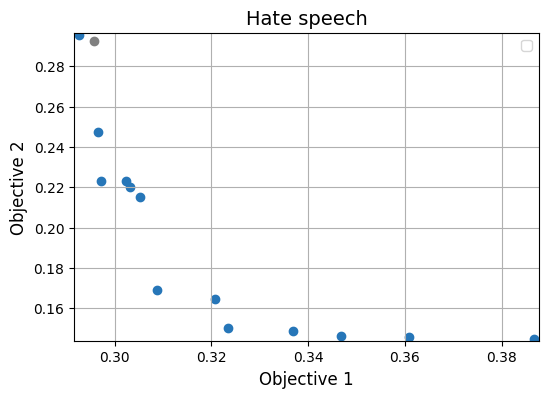

In [4]:
from ml_moo.analysis.pareto_frontier import ParetoFrontier
loss_dt = ParetoFrontier.plot_two_objs(moo_objs=moo_objs, title="Hate speech")